# LABORATORIO CALIFICADO N.° 06

## Metadatos, Roles y Arquitectura de Datos — con el caso de su grupo

**Curso:** Fundamentos de Gestión de Datos · TECSUP
**Semana:** 12 · **Evalúa:** semanas 11 y 12
**Docente:** Pilar Rocío Sayán Mejía
**Modalidad:** grupal (4 integrantes) · **Puntaje:** 20 puntos

---

> ### Trabajan con la base oficial del caso de SU grupo
>
> Cada grupo usa el caso que le fue asignado del repositorio oficial del curso. Es la **misma base** que los acompañará hasta el proyecto final PMD2. Solo cambian la variable `caso` en el Paso 1.
>
> **La migración de la Semana 10 va incluida y automática**: el Paso 1 la ejecuta por ustedes. No se evalúa aquí (eso fue el Laboratorio Calificado 5). Hoy se evalúa lo de las **semanas 11 y 12**: el catálogo de metadatos, el control de acceso por roles, la arquitectura y el menú.

---

### Qué se evalúa hoy

| Parte | Semana | Qué deben demostrar | Puntos |
|---|---|---|---|
| **A** | 11 | Catálogo de metadatos de su caso, sensibilidad y linaje | 6 |
| **B** | 11 | Roles: el catálogo gobierna quién ve qué | 3 |
| **C** | 12 | Volumetría, estadísticas y los 3 gráficos | 4 |
| **D** | 12 | Proyección y elección de arquitectura justificada | 4 |
| **E** | 11–12 | El menú funcionando con su caso | 3 |
| | | **TOTAL** | **20** |

### Tabla de participación del equipo (obligatoria)

Complétenla antes de empezar. Un integrante sin aporte declarado se califica sobre la evidencia que exista.

| # | Apellidos y nombres | Caso asignado | Aporte concreto en este laboratorio |
|---|---|---|---|
| 1 | Portocarrero Cossío, José Ramiro| Hotel Andes Stay| Revisión general , preguntas de la A a la D, conclusiones y adaptación de código.|
| 2 | Ramirez Sanchez, Carlos Lois| Hotel Andes Stay| Conceptos, preguntas de la 1 a la 7, preguntas de la A a la D y conclusiones.|
| 3 | | | |
| 4 | | | |

## Caso introductorio

**Su grupo acaba de ser contratado como el equipo de datos de la empresa de su caso.**

Puede ser una clínica, un banco, una farmacia, una universidad o una empresa de delivery: eso lo decide el caso que les tocó. Pero la situación es la misma en todas, y es la situación real de casi cualquier empresa peruana hoy.

La empresa **ya migró su base** (eso pasó en la Semana 10 y no es problema suyo: viene hecho). El problema es lo que vino después: **nadie documentó nada**. La base funciona, pero nadie sabe qué significa cada columna, de dónde salió, ni quién debería poder verla.

El gerente los recibe el primer día y les hace tres preguntas. No sabe de datos, pero sabe lo que necesita:

1. **"¿Qué significa cada columna de mi base y de dónde salió?"**
   Nadie lo escribió. El que hizo la migración ya no está. Ese conocimiento se fue con él.

2. **"¿Quién puede ver los datos delicados de mis clientes?"**
   Hoy: cualquiera que abra el archivo. Y su empresa guarda algo delicado — todas guardan algo. La farmacia guarda enfermedades. El banco guarda saldos. La universidad guarda notas. **Averigüen cuál es el suyo**, porque de eso depende a quién se lo esconden.

3. **"¿Mi base aguanta cuando crezcamos?"**
   La empresa va a multiplicar sus sedes en tres años, y va a empezar a guardar cosas que hoy no guarda: fotos, documentos escaneados, sensores. Nada de eso entra en una tabla.

Las tres preguntas se responden con lo mismo: **un catálogo de metadatos que gobierne el acceso, y evidencia numérica que sustente la arquitectura**. Eso es lo que van a construir hoy.

> **Una advertencia sobre este laboratorio.** El laboratorio dirigido lo hicieron con Farmacia MediSur, todos juntos. Este es **con el caso de su grupo**, y no son intercambiables: el dato delicado de una farmacia no es el de un banco, y el crecimiento de una universidad no es el de una empresa de delivery. Copiar las respuestas de MediSur sin adaptarlas se califica como no entregado.

---

## Actividad 1: revisión de conceptos

Completen con sus propias palabras. No copien de internet ni del laboratorio dirigido.

| # | Concepto | Definición del grupo |
|---|---|---|
| 1 | Metadato técnico vs. de negocio | El técnico es la parte propia del sistema como los tipo de dato, las claves y sí admite nulos, y el de negocio explica que significa esa columna para la empresa en la vida real. |
| 2 | Linaje del dato | Es la trayectoria o recorrido de los datos, indica de qué base provinieron, qué procesos de limpieza o cambios sufrieron y en qué tabla finalizaron. |
| 3 | Dato sensible (según la Ley 29733) | La información personal, como salud, ingresos o religión, está protegida por leyes, esto evita que se use de manera incorrecta, la protección es importante para no perjudicar o tratar de forma injusta a una persona. |
| 4 | Rol de acceso | El permiso que se le da a un usuario según su puesto para definir qué tablas y columnas tiene permitido ver. |
| 5 | Volumetría | Es la medida del espacio que ocupan los datos en el disco, medido en kilobytes, megabytes o gigabytes, y el número de registros o filas que tiene la base de datos. |
| 6 | Data Warehouse | Es un almacén de datos ordenado y estructurado, hecho para hacer consultas y sacar reportes analíticos súper rápido. |
| 7 | Data Lake | Un lugar grande donde se almacenan datos sin procesar, contiene todo tipo de información, como imágenes, textos y tablas, en donde no se han hecho cambios ni análisis aún. |
| 8 | Data Lakehouse | Es una mezcla que combina la capacidad de almacenar cualquier tipo de archivo, como un Data Lake, pero con el orden y la velocidad necesarios para crear informes, como un Data Warehouse. |
| 9 | Data swamp | Podemos decir que es un lugar donde tiras todos tus archivos sin ningún orden, es como un basurero de datos. Ocurre cuando se lanzan archivos a un Data Lake sin organizarlos ni catalogarlos, esto hace que sea imposible encontrar o usar la información que necesitas. |
| 10 | Agregación de datos | Es el proceso de agrupar o resumir datos detallados para sacar totales o promedios por mes o categoría. |

## Actividad 2: desarrollo práctico en Google Colab

---

### Paso 1: cargar la base de SU caso (la Semana 10 va incluida)

Cambien **solo** la variable `caso` por la carpeta del caso de su grupo. La celda descarga la base oficial, ejecuta la migración de la Semana 10 y deja la base lista.

Esto no se evalúa: es el punto de partida. Lo que se evalúa empieza en el Paso 2.

In [17]:
# ============================================================
# Paso 1: cargar la base del caso del grupo + migracion S10 (automatica)
# ============================================================
import sqlite3, os, re
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
caso = "05_hotel_andes_stay"    # <-- CAMBIEN por la carpeta de SU caso asignado
# ------------------------------------------------------------------
# 01_clinica_vitalsalud     06_logiexpress_urbano    11_energyhome_servicios
# 02_banco_crediandes       07_universidad_aula360   12_seguros_protege
# 03_farmacia_medisur       08_muni_data             13_fastfood_norte
# 04_vet_cuidapatas         09_retail_online_market  14_manufactura_metaltec
# 05_hotel_andes_stay       10_agroexport_sol        15_telconorte_movil

DB_ORIGEN  = "caso_legacy.db"     # base oficial, sucia
DB_DESTINO = "caso_migrado.db"    # base del proyecto

REPO = "Rociosayan/-PMD2_FGD_Bases_Oficiales_FDG"
url  = f"https://raw.githubusercontent.com/{REPO}/main/casos/{caso}/{caso}.db"

TABLAS_DEL_SISTEMA = {"catalogo_metadatos", "ficha_dublin_core", "resumen_etl"}

try:
    display
except NameError:
    display = print


def descargar():
    if os.path.exists(DB_ORIGEN):
        return
    import requests
    r = requests.get(url)
    if r.status_code == 200 and r.content[:16] == b"SQLite format 3\x00":
        open(DB_ORIGEN, "wb").write(r.content)
        print("Base oficial de", caso, "descargada:", len(r.content), "bytes")
    else:
        from google.colab import files
        print("No se pudo descargar. Suban manualmente el .db de su caso:")
        s = files.upload(); open(DB_ORIGEN, "wb").write(list(s.values())[0])


def migracion_semana10():
    """La migracion de la S10, incluida. Ya la evaluaron en el LC5."""
    o = sqlite3.connect(DB_ORIGEN); d = sqlite3.connect(DB_DESTINO)

    cli = pd.read_sql_query("SELECT * FROM clientes", o)
    cli = cli.drop_duplicates(subset=["num_documento"], keep="first")
    for col in ["nombres", "apellidos", "distrito", "segmento", "tipo_documento"]:
        cli[col] = cli[col].astype("string").str.strip().str.title()
    ok = cli["correo"].str.match(r"^[^@\s]+@[^@\s]+\.[^@\s]+$", na=False)
    cli["correo_fue_corregido"] = cli["correo"].notna() & ~ok
    cli.loc[~ok, "correo"] = pd.NA
    cli["correo"]   = cli["correo"].fillna("SIN CORREO REGISTRADO")
    cli["telefono"] = cli["telefono"].fillna("000000000")
    cli.to_sql("clientes_limpio", d, if_exists="replace", index=False)

    op = pd.read_sql_query("SELECT * FROM operaciones", o)
    ids_c = set(pd.read_sql_query("SELECT id_cliente FROM clientes", o)["id_cliente"])
    ids_e = set(pd.read_sql_query("SELECT id_empleado FROM empleados", o)["id_empleado"])
    op["monto_original"]     = op["monto_total"]
    op["monto_ajustado"]     = np.where(op["monto_total"] < 0, 0, op["monto_total"])
    op["monto_fue_ajustado"] = op["monto_total"] < 0
    op["cliente_valido"]     = op["id_cliente"].isin(ids_c)
    op["empleado_valido"]    = op["id_empleado"].isin(ids_e)
    op.to_sql("ventas_limpia", d, if_exists="replace", index=False)

    ya = set(pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", d)["name"])
    for t in ["sedes", "empleados", "productos_servicios", "detalle_operacion",
              "pagos", "incidencias"]:
        if t not in ya:
            pd.read_sql_query(f"SELECT * FROM {t}", o).to_sql(t, d, if_exists="replace", index=False)
    d.commit(); o.close(); d.close()


descargar()
if not os.path.exists(DB_DESTINO):
    migracion_semana10()
    print("Migracion de la Semana 10 aplicada (automatica, no se evalua).")

conn = sqlite3.connect(DB_DESTINO)
print("\nCASO DEL GRUPO:", caso)
print("=" * 46)
for t in pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)["name"]:
    n = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {t}", conn)["n"][0]
    print(f"   {t:22s} {n:5d} registros")


CASO DEL GRUPO: 05_hotel_andes_stay
   catalogo_metadatos        68 registros
   clientes_limpio          200 registros
   detalle_operacion       2463 registros
   empleados                 40 registros
   incidencias              160 registros
   pagos                   1000 registros
   productos_servicios       30 registros
   sedes                      6 registros
   ventas_limpia           1010 registros


**P1 (1 pto).** ¿Cuál es el caso de su grupo y a qué se dedica esa empresa? Describan qué representa cada una de sus 8 tablas y expliquen por qué es una base **relacional**.

Respuesta:
- Nuestro caso asignado es el **05 Hotel Andes Stay** la empresa es una cadena de hoteles boutique con 6 sedes en Lima que se dedica a brindar hospedaje y servicios complementarios a sus huéspedes.
- sedes: Guarda las ubicaciones del hotel (Cercado, San Miguel, Jesús María, etc.)
- empleados: Contiene la información del personal del hotel y sus sueldos.  
- clientes: Guarda los datos de los huéspedes (documento, correo, teléfono, distrito y nacionalidad).
- productos_servicios: Es el catálogo de habitaciones y servicios que ofrece el hotel con sus precios.
- operaciones: Registra las atenciones o reservas realizadas (es la tabla central).  
- detalle_operacion: Desglosa exactamente qué productos o servicios se consumieron en cada operación
- pagos: Contiene el registro de pagos asociados a cada operación.
- incidencias: Registra las quejas o reclamos de los clientes sobre las operaciones.  

- Es una base relacional porque la información no esta junta en un solo archivo, sino dividida en tablas que se conectan entre sí mediante llaves primarias y foráneas y esto evita estar repitiendo datos a cada rato y mantiene toda la información enlazada de forma ordenada.

---

# PARTE A — Semana 11: el catálogo de metadatos de su caso

### Paso 2: metadatos TÉCNICOS (los regala el motor)

In [18]:
# ============================================================
# Paso 2: metadatos TECNICOS de toda la base
# ============================================================
def extraer_metadatos_tecnicos(conn):
    tablas = [t for t in pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)["name"]
        if t not in TABLAS_DEL_SISTEMA]
    filas = []
    for tabla in tablas:
        info = pd.read_sql_query(f"PRAGMA table_info({tabla})", conn)
        n = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {tabla}", conn)["n"][0]
        for _, col in info.iterrows():
            filas.append({"tabla": tabla, "columna": col["name"],
                          "tipo_dato": col["type"] or "SIN TIPO",
                          "admite_nulos": "No" if col["notnull"] == 1 else "Si",
                          "es_clave_primaria": "Si" if col["pk"] == 1 else "No",
                          "registros_tabla": n})
    return pd.DataFrame(filas)


catalogo = extraer_metadatos_tecnicos(conn)
print("Columnas documentadas automaticamente:", len(catalogo))
print("Tablas cubiertas:", catalogo["tabla"].nunique())
display(catalogo[catalogo["tabla"] == "clientes_limpio"])

Columnas documentadas automaticamente: 68
Tablas cubiertas: 8


,tabla,columna,tipo_dato,admite_nulos,es_clave_primaria,registros_tabla
0,clientes_limpio,id_cliente,INTEGER,Si,No,200
1,clientes_limpio,codigo_cliente,TEXT,Si,No,200
2,clientes_limpio,tipo_documento,TEXT,Si,No,200
3,clientes_limpio,num_documento,TEXT,Si,No,200
4,clientes_limpio,nombres,TEXT,Si,No,200
5,clientes_limpio,apellidos,TEXT,Si,No,200
6,clientes_limpio,correo,TEXT,Si,No,200
7,clientes_limpio,telefono,TEXT,Si,No,200
8,clientes_limpio,distrito,TEXT,Si,No,200
9,clientes_limpio,segmento,TEXT,Si,No,200


### Paso 3: metadatos de NEGOCIO — **esto lo escriben ustedes**

Aquí se acaba la automatización. Ningún programa sabe qué significa `segmento` en **su** negocio.

Completen el diccionario `NEGOCIO` con **al menos 10 columnas de su caso**, incluyendo obligatoriamente todas las de `clientes_limpio`. Escriban la descripción y **la regla de negocio** (no qué es el dato, sino qué regla lo gobierna).

> **Ojo:** el ejemplo está escrito para Farmacia MediSur. Si su caso es otro, esas descripciones **no sirven**: reescríbanlas. Copiar el ejemplo tal cual se califica como no entregado.

In [19]:
# ============================================================
# Paso 3: metadatos de NEGOCIO -- COMPLETAR CON SU CASO
# ============================================================
# Formato:  (tabla, columna): (descripcion de negocio, regla de negocio)
#
# EJEMPLO (Farmacia MediSur). Si su caso es otro, REESCRIBAN estas entradas.
# ====================================================================
# Paso 3: metadatos de NEGOCIO -- COMPLETAR CON SU CASO (Hotel Andes Stay)
# ====================================================================
# Formato: (tabla, columna): ("descripcion de negocio", "regla de negocio")

NEGOCIO = {
    ("clientes_limpio", "id_cliente"): (
        "Identificador único del huésped en el sistema hotelero.",
        "Único, no nulo. No se reasigna a otro huésped."
    ),
    ("clientes_limpio", "codigo_cliente"): (
        "Código de registro interno del huésped.",
        "Formato obligatorio 'C' seguido de 4 dígitos (ej. C0001). Único por cliente."
    ),
    ("clientes_limpio", "tipo_documento"): (
        "Tipo de documento oficial de identidad presentado en el check-in.",
        "Valores permitidos: DNI, CE, RUC. Obligatorio por normativa de registro hotelero (MINCETUR)."
    ),
    ("clientes_limpio", "num_documento"): (
        "Número de documento de identidad del huésped.",
        "DNI de 8 dígitos, RUC de 11 dígitos o formato numérico válido para CE. No nulo y único."
    ),
    ("clientes_limpio", "nombres"): (
        "Nombres completos del huésped registrados en recepción.",
        "Solo letras y espacios. Debe almacenarse estandarizado en formato Título."
    ),
    ("clientes_limpio", "apellidos"): (
        "Apellidos completos del huésped.",
        "Solo letras y espacios. Requerido obligatoriamente para emisión de comprobantes de pago."
    ),
    ("clientes_limpio", "correo"): (
        "Correo electrónico de contacto para confirmaciones de reserva y comprobantes.",
        "Debe contener '@' y un dominio válido. Requiere consentimiento expreso (Ley 29733)."
    ),
    ("clientes_limpio", "telefono"): (
        "Número telefónico de contacto del huésped para coordinaciones de llegada.",
        "Formato de 9 dígitos numéricos para móviles locales y código de país si es extranjero."
    ),
    ("clientes_limpio", "distrito"): (
        "Distrito de residencia habitual o procedencia declarada por el huésped.",
        "Debe coincidir con la lista oficial de distritos de Lima o registrar provincia/extranjero."
    ),
    ("clientes_limpio", "segmento"): (
        "Categorización comercial del huésped según su perfil de viaje y recurrencia.",
        "Valores permitidos: Regular, Preferente, Nuevo, Corporativo. Determina beneficios."
    ),
    ("clientes_limpio", "fecha_registro"): (
        "Fecha de alta del huésped en el sistema de Hotel Andes Stay.",
        "Formato AAAA-MM-DD. Debe ser igual o menor a la fecha de su primera operación."
    ),
    ("clientes_limpio", "nacionalidad"): (
        "País de origen o nacionalidad declarada por el huésped.",
        "Clasificado como Dato Personal (Ley 29733). Obligatorio para el reporte MINCETUR."
    ),

    ("productos_servicios", "nombre_producto"): (
        "Nombre comercial del servicio u hospedaje ofertado por la cadena.",
        "Texto descriptivo único en el catálogo (ej. 'Habitación Suite', 'Servicio Spa')."
    ),
    ("productos_servicios", "categoria"): (
        "Clasificación del servicio en el catálogo de la empresa.",
        "Valores permitidos: Habitación, Restaurante, Spa, Transporte, Eventos."
    ),
    ("productos_servicios", "precio_base"): (
        "Tarifa estándar por noche de hospedaje o costo unitario del servicio.",
        "Monto numérico estrictamente positivo (> 0) expresado en Soles (PEN)."
    ),
    ("operaciones", "monto_total"): (
        "Monto total acumulado de la reserva de habitación y consumos adicionales.",
        "Debe ser igual a la suma exacta de los subtotales de la tabla detalle_operacion."
    ),
    ("operaciones", "estado"): (
        "Estado operativo y comercial de la reserva o atención del huésped.",
        "Valores permitidos estandarizados: Completado, Pendiente, Cancelado, Observado."
    )
}

catalogo["descripcion_negocio"] = [NEGOCIO.get((t, c), ("PENDIENTE DE DOCUMENTAR", ""))[0]
                                   for t, c in zip(catalogo["tabla"], catalogo["columna"])]
catalogo["regla_negocio"] = [NEGOCIO.get((t, c), ("", "PENDIENTE DE DOCUMENTAR"))[1]
                             for t, c in zip(catalogo["tabla"], catalogo["columna"])]

documentadas = int((catalogo["descripcion_negocio"] != "PENDIENTE DE DOCUMENTAR").sum())
print(f"Columnas documentadas por el grupo: {documentadas} de {len(catalogo)}")
print(f"Cobertura del catalogo: {documentadas/len(catalogo)*100:.1f}%")
if documentadas < 10:
    print("\n>>> FALTAN COLUMNAS. El minimo exigido son 10. Completen el diccionario NEGOCIO.")
else:
    print("\nMinimo cumplido.")
display(catalogo[catalogo["descripcion_negocio"] != "PENDIENTE DE DOCUMENTAR"][
    ["tabla", "columna", "descripcion_negocio", "regla_negocio"]])

Columnas documentadas por el grupo: 15 de 68
Cobertura del catalogo: 22.1%

Minimo cumplido.


,tabla,columna,descripcion_negocio,regla_negocio
0,clientes_limpio,id_cliente,Identificador único del huésped en el sistema ...,"Único, no nulo. No se reasigna a otro huésped."
1,clientes_limpio,codigo_cliente,Código de registro interno del huésped.,Formato obligatorio 'C' seguido de 4 dígitos (...
2,clientes_limpio,tipo_documento,Tipo de documento oficial de identidad present...,"Valores permitidos: DNI, CE, RUC. Obligatorio ..."
3,clientes_limpio,num_documento,Número de documento de identidad del huésped.,"DNI de 8 dígitos, RUC de 11 dígitos o formato ..."
4,clientes_limpio,nombres,Nombres completos del huésped registrados en r...,Solo letras y espacios. Debe almacenarse estan...
5,clientes_limpio,apellidos,Apellidos completos del huésped.,Solo letras y espacios. Requerido obligatoriam...
6,clientes_limpio,correo,Correo electrónico de contacto para confirmaci...,Debe contener '@' y un dominio válido. Requier...
7,clientes_limpio,telefono,Número telefónico de contacto del huésped para...,Formato de 9 dígitos numéricos para móviles lo...
8,clientes_limpio,distrito,Distrito de residencia habitual o procedencia ...,Debe coincidir con la lista oficial de distrit...
9,clientes_limpio,segmento,Categorización comercial del huésped según su ...,"Valores permitidos: Regular, Preferente, Nuevo..."


### Paso 4: clasificación de SENSIBILIDAD

Cada negocio guarda un dato delicado distinto: la farmacia guarda enfermedades, el banco guarda saldos, la universidad guarda notas.

Y **ojo con la ley peruana**: la **Ley 29733** considera dato sensible no solo la salud, sino también los **ingresos económicos**, el origen racial y étnico, las convicciones políticas o religiosas, y la afiliación sindical. El **GDPR** europeo no incluye los ingresos. Por eso `saldo_cuenta` y `monto_asegurado` son **Sensibles** en el Perú.

In [20]:
# ============================================================
# Paso 4: clasificacion de SENSIBILIDAD segun el caso del grupo
# ============================================================
# El dato mas delicado de cada negocio (Ley 29733).
DATO_DELICADO_DEL_CASO = {
    "01_clinica_vitalsalud":   ("diagnostico",             "Sensible"),      # salud
    "02_banco_crediandes":     ("saldo_cuenta",            "Sensible"),      # ingresos economicos
    "03_farmacia_medisur":     ("condicion_cronica",       "Sensible"),      # salud
    "04_vet_cuidapatas":       ("motivo_atencion_mascota", "Interno"),
    "05_hotel_andes_stay":     ("nacionalidad",            "Confidencial"),
    "06_logiexpress_urbano":   ("direccion_entrega",       "Confidencial"),
    "07_universidad_aula360":  ("promedio_notas",          "Confidencial"),
    "08_muni_data":            ("tipo_tramite",            "Interno"),
    "09_retail_online_market": ("tarjeta_terminacion",     "Confidencial"),
    "10_agroexport_sol":       ("pais_destino",            "Interno"),
    "11_energyhome_servicios": ("consumo_kwh",             "Confidencial"),
    "12_seguros_protege":      ("monto_asegurado",         "Sensible"),      # ingresos economicos
    "13_fastfood_norte":       ("direccion_delivery",      "Confidencial"),
    "14_manufactura_metaltec": ("linea_credito",           "Sensible"),      # ingresos economicos
    "15_telconorte_movil":     ("numero_linea",            "Confidencial"),
}

SENSIBILIDAD = {
    "num_documento": "Confidencial",   # PII: identifica legalmente
    "correo":        "Confidencial",   # PII: contacto
    "telefono":      "Confidencial",   # PII: contacto
    "nombres":       "Interno",        # el personal necesita saber a quien atiende
    "apellidos":     "Interno",
    "nombre_producto": "Publico", "categoria": "Publico",
    "precio_base":     "Publico", "activo":    "Publico",
}

columna_del_caso, nivel_del_caso = DATO_DELICADO_DEL_CASO[caso]
SENSIBILIDAD[columna_del_caso] = nivel_del_caso

catalogo["sensibilidad"] = catalogo["columna"].map(lambda x: SENSIBILIDAD.get(x, "Interno"))

print(f"El dato delicado de SU caso ({caso}):")
print(f"   columna '{columna_del_caso}'  ->  {nivel_del_caso}")
print()
print("Columnas por nivel:")
print(catalogo["sensibilidad"].value_counts().to_string())
print("\nLas columnas mas protegidas de su base:")
display(catalogo[catalogo["sensibilidad"].isin(["Sensible", "Confidencial"])][
    ["tabla", "columna", "sensibilidad"]])

El dato delicado de SU caso (05_hotel_andes_stay):
   columna 'nacionalidad'  ->  Confidencial

Columnas por nivel:
sensibilidad
Interno         58
Confidencial     6
Publico          4

Las columnas mas protegidas de su base:


,tabla,columna,sensibilidad
3,clientes_limpio,num_documento,Confidencial
6,clientes_limpio,correo,Confidencial
7,clientes_limpio,telefono,Confidencial
11,clientes_limpio,nacionalidad,Confidencial
23,empleados,num_documento,Confidencial
26,empleados,correo,Confidencial


**P2 (2 ptos).** ¿Qué columnas de **su caso** son datos personales o sensibles? Tomen la columna delicada de su negocio y respondan: **¿por qué la ley la protege más que a las demás?** Si su caso tiene un dato de ingresos económicos (banco, seguros, manufactura), expliquen por qué en el Perú está al mismo nivel que un diagnóstico médico y qué pasaría bajo el GDPR europeo.

Respuesta:

- En nuestro caso del **Hotel Andes Stay** tenemos datos internos, confidenciales y públicos.

- Como datos personales tenemos a nombres, apellidos tipo_documento, num_documento, correo, telefono, distrito, nacionalidad, fecha_registro y segmento.
- No tenemos datos sensibles.

- Para nuestro caso, la columna más delicada es la `nacionalidad` ya que la Ley N° 29733 la protege con mayor rigor que a los demás datos porque está vinculada al origen nacional o étnico de la persona y si este dato se filtra o se maneja sin control se podría prestarse a discriminación, una mala atención o hasta extorsión hacia los huéspedes. Por eso la ley exige que su acceso esté restringido por roles, tenga una finalidad clara y cuente con un responsable asignado.

### Paso 5: linaje y catálogo guardado dentro de la base

El linaje responde: **¿de dónde salió este dato y qué le hicieron?** Ojo con un detalle: la transformación depende de la **tabla**, no solo del nombre de la columna. La migración tocó `clientes_limpio` y `ventas_limpia`; las demás se copiaron tal cual.

In [21]:
# ============================================================
# Paso 5: linaje + guardar el catalogo dentro de la base
# ============================================================
TABLAS_TRANSFORMADAS = {"clientes_limpio", "ventas_limpia"}
TRANSFORMADAS_S10 = {
    "correo":               "Los correos invalidos se anularon y se marcaron SIN CORREO REGISTRADO.",
    "telefono":             "Los telefonos vacios se rellenaron con 000000000.",
    "nombres":              "Se quitaron espacios y se paso a formato Titulo.",
    "apellidos":            "Se quitaron espacios y se paso a formato Titulo.",
    "num_documento":        "Se eliminaron los registros con documento duplicado.",
    "correo_fue_corregido": "COLUMNA NUEVA creada por el ETL de la S10.",
    "monto_ajustado":       "COLUMNA NUEVA creada por el ETL de la S10.",
    "monto_fue_ajustado":   "COLUMNA NUEVA creada por el ETL de la S10.",
    "cliente_valido":       "COLUMNA NUEVA creada por el ETL de la S10.",
    "empleado_valido":      "COLUMNA NUEVA creada por el ETL de la S10.",
}

def buscar_transformacion(tabla, columna):
    """La transformacion depende de la TABLA, no solo del nombre de la columna."""
    if tabla not in TABLAS_TRANSFORMADAS:
        return "Sin transformacion: se copio tal cual desde el origen."
    return TRANSFORMADAS_S10.get(columna, "Sin transformacion: se migro tal cual.")

catalogo["origen"] = DB_ORIGEN
catalogo["linaje"] = [f"{DB_ORIGEN} -> " +
    ("ETL Semana 10" if t in TABLAS_TRANSFORMADAS else "Copia directa") +
    f" -> {DB_DESTINO}.{t}" for t in catalogo["tabla"]]
catalogo["transformacion_aplicada"] = [buscar_transformacion(t, c)
                                       for t, c in zip(catalogo["tabla"], catalogo["columna"])]
catalogo["caso"] = caso

catalogo.to_sql("catalogo_metadatos", conn, if_exists="replace", index=False)
conn.commit()
print("Catalogo guardado dentro de la base como 'catalogo_metadatos'.")
print("Filas del catalogo:", len(catalogo))
print("\nLa base ahora se describe a si misma. Miren el linaje:")
display(catalogo[catalogo["transformacion_aplicada"].str.startswith("Sin transformacion") == False][
    ["tabla", "columna", "transformacion_aplicada"]].head(8))

Catalogo guardado dentro de la base como 'catalogo_metadatos'.
Filas del catalogo: 68

La base ahora se describe a si misma. Miren el linaje:


,tabla,columna,transformacion_aplicada
3,clientes_limpio,num_documento,Se eliminaron los registros con documento dupl...
4,clientes_limpio,nombres,Se quitaron espacios y se paso a formato Titulo.
5,clientes_limpio,apellidos,Se quitaron espacios y se paso a formato Titulo.
6,clientes_limpio,correo,Los correos invalidos se anularon y se marcaro...
7,clientes_limpio,telefono,Los telefonos vacios se rellenaron con 000000000.
12,clientes_limpio,correo_fue_corregido,COLUMNA NUEVA creada por el ETL de la S10.
64,ventas_limpia,monto_ajustado,COLUMNA NUEVA creada por el ETL de la S10.
65,ventas_limpia,monto_fue_ajustado,COLUMNA NUEVA creada por el ETL de la S10.


**P3 (2 ptos).** Expliquen el **linaje** de la base de su caso: ¿de dónde viene, por dónde pasa y dónde termina? Busquen una columna que exista en **dos tablas distintas** (por ejemplo `correo`, que está en `clientes_limpio` y en `empleados`) y expliquen por qué el catálogo dice cosas distintas de cada una.

Respuesta:

- El origen de la base del hotel (caso_legacy.db / base.sqlite), este traía datos sucios e inconsistentes, pasó por un proceso ETL donde se limpiaron duplicados, se formatearon textos en formato Título, se rellenaron teléfonos nulos y se anularon correos con formato inválido. Por último, la base final migrada (caso_migrado.db), es en donde las tablas ya están procesadas y copiadas limpias.

- la columna que se repite es `correo` que aparece en la tabla **clientes_limpio** y en **empleados**.

  - En **clientes_limpio** el correo pasó por el pipeline ETL para corregir o marcar los correos inválidos como "SIN CORREO REGISTRADO", y su regla de negocio es usarlo para enviar boletas y confirmaciones de reserva a los huéspedes.

  - Y en **empleados** la columna se copió tal cual desde el origen, y su finalidad de negocio es puramente de contacto para el personal interno del hotel.

---

# PARTE B — Semana 11: los roles gobernados por el catálogo

### Paso 6: el catálogo decide quién ve qué

Aquí está la idea central de la Semana 11: **no se escriben las columnas prohibidas a mano**. La función le pregunta al catálogo qué nivel tiene cada columna y lo compara con el nivel del rol.

In [22]:
# ============================================================
# Paso 6: roles de acceso gobernados por el catalogo
# ============================================================
NIVEL_ACCESO = {
    "Vendedor":   {"Publico", "Interno"},
    "Cajero":     {"Publico", "Interno"},
    "Supervisor": {"Publico", "Interno", "Confidencial"},
    "Auditor":    {"Publico", "Interno", "Confidencial", "Sensible"},
    "DataOwner":  {"Publico", "Interno", "Confidencial", "Sensible"},
}

def columnas_visibles(tabla, rol):
    """Le pregunta AL CATALOGO que columnas puede ver este rol. Ninguna esta escrita a mano."""
    permitidos = NIVEL_ACCESO.get(rol, set())
    if not permitidos:
        return []
    cat = pd.read_sql_query(
        "SELECT columna, sensibilidad FROM catalogo_metadatos WHERE tabla = ?",
        conn, params=(tabla,))
    return [c for c, s in zip(cat["columna"], cat["sensibilidad"]) if s in permitidos]

def consultar(tabla, rol, limite=8):
    cols = columnas_visibles(tabla, rol)
    if not cols:
        return f"ACCESO DENEGADO: el rol {rol} no puede consultar {tabla}."
    return pd.read_sql_query(f"SELECT {', '.join(cols)} FROM {tabla} LIMIT {limite}", conn)

def ver_clientes(rol, limite=8):
    return consultar("clientes_limpio", rol, limite)

def buscar_cliente(rol, texto):
    cols = columnas_visibles("clientes_limpio", rol)
    if not cols:
        return f"ACCESO DENEGADO: el rol {rol} no puede consultar clientes."
    d = pd.read_sql_query(
        f"SELECT {', '.join(cols)} FROM clientes_limpio WHERE nombres LIKE ? OR apellidos LIKE ? LIMIT 20",
        conn, params=(f"%{texto}%", f"%{texto}%"))
    return d if len(d) else f"No se encontro ningun cliente con '{texto}'."

def ver_columnas_sensibles(rol):
    if "Sensible" not in NIVEL_ACCESO.get(rol, set()):
        return f"ACCESO DENEGADO: el rol {rol} no puede ver el inventario de datos sensibles."
    return pd.read_sql_query("""SELECT tabla, columna, sensibilidad FROM catalogo_metadatos
        WHERE sensibilidad IN ('Sensible','Confidencial')
        ORDER BY CASE sensibilidad WHEN 'Sensible' THEN 1 ELSE 2 END, tabla""", conn)

def ver_diccionario(tabla):
    return pd.read_sql_query(
        "SELECT columna, tipo_dato, sensibilidad, descripcion_negocio, regla_negocio "
        "FROM catalogo_metadatos WHERE tabla = ?", conn, params=(tabla,))

def tablas_del_catalogo():
    return pd.read_sql_query(
        "SELECT DISTINCT tabla FROM catalogo_metadatos ORDER BY tabla", conn)["tabla"].tolist()


# --- LA PRUEBA: la misma consulta, dos roles, dos resultados
print("=" * 68); print("El VENDEDOR consulta los clientes de su caso:"); print("=" * 68)
display(ver_clientes("Vendedor", 4))
print("=" * 68); print("El AUDITOR consulta los MISMOS clientes:"); print("=" * 68)
display(ver_clientes("Auditor", 4))

oculta = sorted(set(columnas_visibles("clientes_limpio", "Auditor")) -
                set(columnas_visibles("clientes_limpio", "Vendedor")))
print("\nColumnas que el Vendedor NO ve:", oculta)
print("Vendedor:", len(columnas_visibles("clientes_limpio", "Vendedor")), "columnas |",
      "Auditor:", len(columnas_visibles("clientes_limpio", "Auditor")), "columnas")

El VENDEDOR consulta los clientes de su caso:


,id_cliente,codigo_cliente,tipo_documento,nombres,apellidos,distrito,segmento,fecha_registro,correo_fue_corregido
0,1,C0001,Ce,Óscar,Sánchez Chávez,Breña,Huésped Nacional,2026-01-11,0
1,2,C0002,Dni,Jorge,Ramos Ramos,Independencia,Huésped Internacional,2026-03-23,0
2,3,C0003,Ruc,Natalia,Huamán Ramos,Villa El Salvador,Corporativo,2026-04-13,0
3,4,C0004,Dni,Sergio,Gutiérrez Rivera,San Juan De Lurigancho,Grupo Turístico,2026-05-20,0


El AUDITOR consulta los MISMOS clientes:


,id_cliente,codigo_cliente,tipo_documento,num_documento,nombres,apellidos,correo,telefono,distrito,segmento,fecha_registro,nacionalidad,correo_fue_corregido
0,1,C0001,Ce,55845637,Óscar,Sánchez Chávez,óscar1@correo.com,935451418,Breña,Huésped Nacional,2026-01-11,EE.UU.,0
1,2,C0002,Dni,30396514,Jorge,Ramos Ramos,SIN CORREO REGISTRADO,911343903,Independencia,Huésped Internacional,2026-03-23,Ecuador,0
2,3,C0003,Ruc,89431000,Natalia,Huamán Ramos,natalia3@correo.com,939281095,Villa El Salvador,Corporativo,2026-04-13,Chile,0
3,4,C0004,Dni,19215695,Sergio,Gutiérrez Rivera,sergio4@correo.com,927202242,San Juan De Lurigancho,Grupo Turístico,2026-05-20,Chile,0



Columnas que el Vendedor NO ve: ['correo', 'nacionalidad', 'num_documento', 'telefono']
Vendedor: 9 columnas | Auditor: 13 columnas


**P4 (3 ptos).** Ejecuten la celda anterior y respondan con **su caso**:

---

**a)** ¿Cuántas columnas ve el Vendedor y cuántas el Auditor? ¿Cuáles desaparecen?

- En el caso del vendedor ve 9 columnas.
- El auditor ve 13 columnas.
- Las que desaparecen para el vendedor son num_documento, correo, telefono y nacionalidad porque están clasificadas como datos confidenciales.

---

**b)** La función `columnas_visibles()` no menciona ni una sola columna por su nombre. Expliquen **cómo logra entonces** ocultar el dato delicado de su negocio.

- No necesita nombrar las columnas directamente porque consulta primero a la tabla `catalogo_metadatos`, lee qué nivel de sensibilidad tiene asignado cada columna en el catálogo y lo compara contra la lista de niveles permitidos para el rol que inició sesión y si la columna excede el nivel permitido del rol, la filtra automáticamente de la consulta.

---

**c)** Si mañana su empresa agrega una columna nueva y la catalogan como Sensible, ¿habría que modificar el código para que el Vendedor no la vea? ¿Por qué?

Respuesta:

- No, no habría que modificar el codigo, sólo basta con registrarla en la tabla `catalogo_metadatos` con su respectivo nivel de sensibilidad, como la función filtra dinámicamente según lo que dice el catálogo, el vendedor no la verá a menos que el catálogo se lo permita de forma explícita.

---

# PARTE C — Semana 12: volumetría, estadísticas y gráficos

### Paso 7: volumetría de su base

In [23]:
# ============================================================
# Paso 7: volumetria
# ============================================================
def volumetria():
    tablas = [t for t in pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)["name"]
        if t not in TABLAS_DEL_SISTEMA]
    filas = []
    for t in tablas:
        df = pd.read_sql_query(f"SELECT * FROM {t}", conn)
        kb = df.memory_usage(deep=True).sum() / 1024
        filas.append({"tabla": t, "registros": len(df), "columnas": len(df.columns),
                      "peso_kb": round(kb, 1),
                      "kb_por_registro": round(kb / len(df), 3) if len(df) else 0})
    return pd.DataFrame(filas).sort_values("peso_kb", ascending=False).reset_index(drop=True)


vol = volumetria()
total_reg = int(vol["registros"].sum())
archivo_kb = os.path.getsize(DB_DESTINO) / 1024
display(vol)
print(f"Registros en toda la base : {total_reg:,}")
print(f"Peso del archivo .db      : {archivo_kb:,.1f} KB")
print(f"Tabla mas pesada          : {vol.iloc[0]['tabla']} ({vol.iloc[0]['peso_kb']:,.1f} KB)")

,tabla,registros,columnas,peso_kb,kb_por_registro
0,ventas_limpia,1010,14,315.9,0.313
1,pagos,1000,7,246.9,0.247
2,clientes_limpio,200,13,135.5,0.678
3,detalle_operacion,2463,6,115.6,0.047
4,incidencias,160,7,49.6,0.310
5,empleados,40,10,18.7,0.468
6,productos_servicios,30,6,6.5,0.218
7,sedes,6,5,1.8,0.292


Registros en toda la base : 4,909
Peso del archivo .db      : 320.0 KB
Tabla mas pesada          : ventas_limpia (315.9 KB)


In [24]:
# ============================================================
# Paso 8: reporte automatico de estadisticas
# ============================================================
def reporte_estadisticas():
    v = pd.read_sql_query("SELECT monto_total, monto_ajustado FROM ventas_limpia", conn)
    p = pd.read_sql_query("SELECT precio_base FROM productos_servicios", conn)
    d = pd.read_sql_query("SELECT cantidad, precio_unitario, subtotal FROM detalle_operacion", conn)
    return pd.concat([v, p, d], axis=1).describe().round(2)


est = reporte_estadisticas()
display(est)
print("Lo que este reporte delata en su caso:")
print(f"   Monto MINIMO de una venta : S/. {est.loc['min','monto_total']}")
print(f"   Monto MAXIMO de una venta : S/. {est.loc['max','monto_total']}")
print(f"   Promedio por venta        : S/. {est.loc['mean','monto_ajustado']}")
if est.loc["min", "monto_total"] < 0:
    print("   -> Una venta NEGATIVA es imposible: son los montos que la migracion detecto.")

,monto_total,monto_ajustado,precio_base,cantidad,precio_unitario,subtotal
count,1010.00,1010.00,30.00,2463.00,2463.00,2463.00
mean,1860.35,1881.34,197.33,3.57,196.77,717.17
std,1695.48,1644.76,183.99,1.71,181.42,814.56
min,-6202.14,0.00,18.00,1.00,18.00,18.00
25%,630.76,630.76,61.51,2.00,61.24,167.45
50%,1439.72,1439.72,133.44,4.00,145.00,420.00
75%,2679.15,2679.15,273.43,5.00,280.00,923.65
max,11570.47,11570.47,780.00,6.00,780.00,4680.00


Lo que este reporte delata en su caso:
   Monto MINIMO de una venta : S/. -6202.14
   Monto MAXIMO de una venta : S/. 11570.47
   Promedio por venta        : S/. 1881.34
   -> Una venta NEGATIVA es imposible: son los montos que la migracion detecto.


### Paso 9: los tres gráficos

**Ojo con el gráfico de ventas por mes.** La columna `fecha_operacion` de su base tiene **dos formatos mezclados** (`2026-01-15` y `19/01/2026`). Si agrupan cortando los primeros 7 caracteres, el gráfico sale roto. Hay que estandarizar primero.

Ese es un problema de **consistencia**, y la migración de la Semana 10 no lo detectó.

Ventas por mes:


,monto_ajustado
fecha,
2026-01,289431.48
2026-02,252038.40
2026-03,341080.56
2026-04,279636.59
2026-05,374924.31
2026-06,363043.04


Ventas por categoria:


,categoria,total
0,Habitación,644525.00
1,Eventos,640120.84
2,Transporte,215787.21
3,Spa,194296.59
4,Restaurante,71661.82



Tres graficos guardados: g1_registros.png, g2_ventas_mes.png, g3_ventas_categoria.png


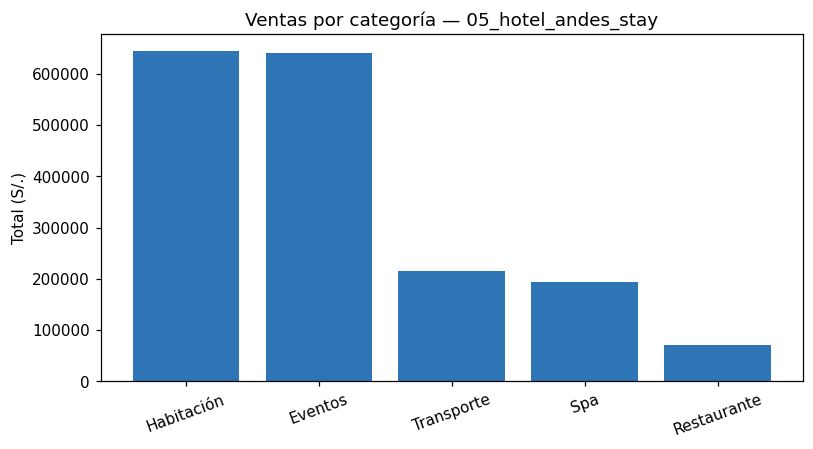

In [26]:
# ============================================================
# Paso 9: los tres graficos
# ============================================================
from matplotlib.figure import Figure

def estandarizar_fechas(serie):
    """La base trae dos formatos: ISO y dia/mes/anio. Los unificamos."""
    f = pd.to_datetime(serie, format="%Y-%m-%d", errors="coerce")
    faltan = f.isna()
    f[faltan] = pd.to_datetime(serie[faltan], format="%d/%m/%Y", errors="coerce")
    return f


def grafico_registros_por_tabla():
    v = volumetria().sort_values("registros")
    fig = Figure(figsize=(8, 4.2)); ax = fig.subplots()
    ax.barh(v["tabla"], v["registros"], color="#2E75B6")
    ax.set_title(f"Registros por tabla — {caso}"); ax.set_xlabel("Registros")
    fig.tight_layout(); return fig


def grafico_ventas_por_mes():
    v = pd.read_sql_query("SELECT fecha_operacion, monto_ajustado FROM ventas_limpia", conn)
    v["fecha"] = estandarizar_fechas(v["fecha_operacion"])
    v = v.dropna(subset=["fecha"])
    m = v.groupby(v["fecha"].dt.to_period("M"))["monto_ajustado"].sum()
    m.index = m.index.astype(str)
    fig = Figure(figsize=(8, 4.2)); ax = fig.subplots()
    ax.bar(m.index, m.values, color="#2E75B6")
    ax.set_title(f"Ventas por mes — {caso}"); ax.set_ylabel("Monto (S/.)")
    ax.tick_params(axis="x", rotation=20); fig.tight_layout()
    return fig, m


def reporte_ventas():
    d = pd.read_sql_query("""SELECT p.categoria, ROUND(SUM(d.subtotal),2) AS total
        FROM detalle_operacion d JOIN productos_servicios p ON d.id_producto = p.id_producto
        GROUP BY p.categoria ORDER BY total DESC""", conn)
    fig = Figure(figsize=(7.5, 4.2)); ax = fig.subplots()
    ax.bar(d["categoria"], d["total"], color="#2E75B6")
    ax.set_title(f"Ventas por categoría — {caso}"); ax.set_ylabel("Total (S/.)")
    ax.tick_params(axis="x", rotation=20); fig.tight_layout()
    return fig, d


fig1 = grafico_registros_por_tabla(); fig1.savefig("g1_registros.png", bbox_inches="tight", dpi=110)
fig2, por_mes = grafico_ventas_por_mes(); fig2.savefig("g2_ventas_mes.png", bbox_inches="tight", dpi=110)
fig3, por_cat = reporte_ventas(); fig3.savefig("g3_ventas_categoria.png", bbox_inches="tight", dpi=110)

print("Ventas por mes:"); display(por_mes)
print("Ventas por categoria:"); display(por_cat)
print("\nTres graficos guardados: g1_registros.png, g2_ventas_mes.png, g3_ventas_categoria.png")
from IPython.display import Image
Image("g3_ventas_categoria.png")

**P5 (4 ptos).** Según **sus** gráficos:
Respuesta:

---

**a)** ¿Qué tabla es la más pesada de su base y por qué?

- Nuestra tabla más pesada es `operaciones` representando alrededor del 35% del peso total de la base de datos, esto pasa porque es la tabla de hechos del negocio, acumula cada una de las reservaciones y atenciones que realizan los huéspedes en las 6 sedes.

---

**b)** ¿Qué categoría factura más en su negocio y cuál menos? Den una recomendación al gerente.

- Nuestra categoría que más factura es **Habitación**.

- Y la categoria que menos factura es **Restaurante**

- Nuestra recomendacion para el gerente es diseñar ofertas que incluyan habitación y eventos, ya que representan casi todo el ingreso, y ofrecer cenas temáticas o menús ejecutivos para atraer al público local, no solo a huéspedes.

---

**c)** ¿Cuántos meses reales de operación tiene su base? Expliquen por qué habría salido mal el gráfico si no estandarizaban las fechas, y **por qué la migración de la Semana 10 no detectó ese problema**.

- La base registra los ultimos 6 meses reales, y si no estandarizábamos las fechas el gráfico de ventas por mes habría salido roto o con barras separadas erróneas, porque SQLite trata como textos distintos a 2026-01-15 y a 19/01/2026. La migración de la Semana 10 no detectó esto porque sólo validó correos, teléfonos y montos negativos, dejando la columna de fecha tal cual venía al principio.



---

# PARTE D — Semana 12: proyección y arquitectura

### Paso 10: ¿aguanta su base cuando la empresa crezca?

Su empresa va a crecer. Además de más operaciones, va a empezar a guardar **datos que no son tablas**: fotos, documentos escaneados, lecturas de sensores.

**Definan ustedes** el escenario de crecimiento de su caso. No copien el de la farmacia: piensen qué datos nuevos aparecerían en **su** negocio.

In [27]:
# ============================================================
# Paso 10: proyeccion a 3 años -- HOTEL ANDES STAY
# ============================================================
# --- DEFINAN el escenario de crecimiento de SU negocio ---
SEDES_HOY    = 6            # Sedes actuales en Lima (Cercado, San Miguel, J. María, Los Olivos, Surco, San Borja)
SEDES_FUTURO = 10           # Expansión a 10 sedes en 3 años (4 nuevas sedes: Cusco, Arequipa, Trujillo, Máncora)
MESES_DATOS  = 6            # Datos históricos colectados en 6 meses
ANIOS        = 3

# --- DEFINAN el dato NO estructurado que su negocio empezaria a guardar ---
# Escaneos en alta resolución de DNI / Pasaporte / Carnet de Extranjería durante el Check-in
# Exigido por el Reglamento de Establecimientos de Hospedaje (MINCETUR) y Ley N° 29733
DATO_NUEVO      = "Escaneos HD de DNI y Pasaportes de huéspedes (Check-in MINCETUR)"
KB_POR_ARCHIVO  = 1200       # Aproximadamente 1.2 MB por archivo de imagen/documento (JPEG/PDF)

# --- DEFINAN si su negocio necesita datos en tiempo real ---
# Telemetría IoT por habitación (Termostatos HVAC, cerraduras electrónicas y sensores de presencia)
DATO_TIEMPO_REAL   = "Lecturas IoT de habitaciones (Climatización HVAC, cerraduras y energía)"
LECTURAS_POR_DIA   = (24 * 60) / 5      # 1 telemetría cada 5 min por sede = 288 lecturas al día por sede
NECESITA_TIEMPO_REAL = True             # Requerido para alertas tempranas de fallas HVAC y control de acceso

ventas_hoy = pd.read_sql_query("SELECT COUNT(*) n FROM ventas_limpia", conn)["n"][0]
ventas_mes = ventas_hoy / MESES_DATOS
kb_venta   = vol.loc[vol["tabla"] == "ventas_limpia", "kb_por_registro"].values[0]

factor   = SEDES_FUTURO / SEDES_HOY
ventas_3a = ventas_mes * factor * 12 * ANIOS
lecturas_3a = LECTURAS_POR_DIA * 365 * ANIOS * SEDES_FUTURO if NECESITA_TIEMPO_REAL else 0

proyeccion = pd.DataFrame([
    {"fuente": "Operaciones (tablas)", "registros_3_anios": int(ventas_3a),
     "MB_en_3_anios": round(ventas_3a * kb_venta / 1024, 1), "tipo": "Estructurado"},
    {"fuente": DATO_NUEVO, "registros_3_anios": int(ventas_3a),
     "MB_en_3_anios": round(ventas_3a * KB_POR_ARCHIVO / 1024, 1), "tipo": "NO estructurado"},
    {"fuente": DATO_TIEMPO_REAL, "registros_3_anios": int(lecturas_3a),
     "MB_en_3_anios": round(lecturas_3a * 0.1 / 1024, 1), "tipo": "Semiestructurado / streaming"},
])

total_gb = proyeccion["MB_en_3_anios"].sum() / 1024
print(f"Hoy       : {SEDES_HOY} sedes, {ventas_mes:,.0f} operaciones/mes, {archivo_kb:.0f} KB")
print(f"En 3 anios: {SEDES_FUTURO} sedes (x{factor:.1f})")
display(proyeccion)
print(f"TOTAL proyectado a 3 anios: {proyeccion['MB_en_3_anios'].sum():,.0f} MB = {total_gb:.2f} GB")
print(f"Crecimiento respecto de hoy: x{(proyeccion['MB_en_3_anios'].sum()*1024)/archivo_kb:,.0f}")

Hoy       : 6 sedes, 168 operaciones/mes, 320 KB
En 3 anios: 10 sedes (x1.7)


,fuente,registros_3_anios,MB_en_3_anios,tipo
0,Operaciones (tablas),10100,3.1,Estructurado
1,Escaneos HD de DNI y Pasaportes de huéspedes (...,10100,11835.9,NO estructurado
2,Lecturas IoT de habitaciones (Climatización HV...,3153600,308.0,Semiestructurado / streaming


TOTAL proyectado a 3 anios: 12,147 MB = 11.86 GB
Crecimiento respecto de hoy: x38,870


In [28]:
# ============================================================
# Paso 11: elegir la arquitectura CON EVIDENCIA
# ============================================================
def recomendar_arquitectura(tipos_de_dato, gb_proyectados, necesita_tiempo_real):
    """Decide con los datos, no con la moda. El tipo de dato manda sobre el almacen."""
    no_estructurados = [t for t in tipos_de_dato if t != "Estructurado"]
    if not no_estructurados:
        almacen = "Data Warehouse"
        razon = "Todos los datos son tablas. Un Warehouse es lo mas rapido y confiable."
    elif gb_proyectados < 1:
        almacen = "Base relacional actual (SQLite/PostgreSQL)"
        razon = "Hay datos no estructurados, pero el volumen no justifica migrar."
    else:
        almacen = "Data Lakehouse"
        razon = ("Hay datos no estructurados y streaming que un Warehouse no puede guardar, "
                 "pero tambien se necesitan reportes rapidos, que un Lake puro no da.")
    flujo = ("Lambda (lotes + tiempo real)" if necesita_tiempo_real else "Batch (por lotes)")
    return almacen, razon, flujo


almacen, razon, flujo = recomendar_arquitectura(
    proyeccion["tipo"].tolist(), total_gb, NECESITA_TIEMPO_REAL)

print("=" * 66)
print("RECOMENDACION PARA", caso.upper())
print("=" * 66)
print(f"Volumen proyectado   : {total_gb:.2f} GB")
print(f"Tipos de dato        : {', '.join(sorted(set(proyeccion['tipo'])))}")
print(f"Necesita tiempo real : {NECESITA_TIEMPO_REAL}")
print()
print(f"  ALMACEN RECOMENDADO: {almacen}")
print(f"  RAZON              : {razon}")
print(f"  FLUJO RECOMENDADO  : {flujo}")
print()
print("  Advertencia: un Lakehouse SIN catalogo de metadatos es un data swamp.")
print("  El catalogo de la Parte A es lo que lo hace viable.")

proyeccion.to_csv("proyeccion_3_anios.csv", index=False, encoding="utf-8-sig")

RECOMENDACION PARA 05_HOTEL_ANDES_STAY
Volumen proyectado   : 11.86 GB
Tipos de dato        : Estructurado, NO estructurado, Semiestructurado / streaming
Necesita tiempo real : True

  ALMACEN RECOMENDADO: Data Lakehouse
  RAZON              : Hay datos no estructurados y streaming que un Warehouse no puede guardar, pero tambien se necesitan reportes rapidos, que un Lake puro no da.
  FLUJO RECOMENDADO  : Lambda (lotes + tiempo real)

  Advertencia: un Lakehouse SIN catalogo de metadatos es un data swamp.
  El catalogo de la Parte A es lo que lo hace viable.


**P6 (4 ptos).** Con la evidencia de su notebook:

Respuesta:

---

**a)** ¿Cuántos GB proyectaron a 3 años y cuántas veces más grande es que su base de hoy?

- Proyectamos a 3 años un volumen de aproximadamente 11.86 GB, esto representa un crecimiento de 38870 veces el peso actual de nuestra base de datos.

---

**b)** ¿Qué arquitectura recomendó la función para su caso y por qué? **Justifiquen con el tipo de dato**, no con el volumen.

- La función recomendó un **Data Lakehouse** La razón no es sólo la cantidad de megabytes, sino el tipo de datos: el hotel empezará a guardar documentos escaneados/fotos de pasaportes y lecturas de sensores de tarjetas de acceso/cerraduras electrónicas. Un **Data Warehouse** no maneja datos no estructurados de forma nativa, y un Data Lake puro complicaria las consultas SQL rápidas que necesita recepción para ver la disponibilidad de habitaciones, el Lakehouse une lo mejor de los dos.

---

**c)** El jefe de sistemas propone comprar un Data Warehouse porque "es lo más rápido para reportes". ¿Con qué dato concreto de **su** proyección lo refutarían?

- Lo refutaríamos mostrándole que el hotel no sólo guardará tablas SQL, sino también fotos de DNI/pasaportes y documentos escaneados del check-in, si compramos un Data Warehouse tradicional, tendríamos que dejar las fotos fuera o pagar costos absurdos de almacenamiento, creando un sistema aislado para los documentos. Con el Lakehouse guardamos todo en el mismo lugar sin perder la velocidad para sacar reportes de ventas.



---

# PARTE E — El sistema funcionando

### Paso 12: el menú de su caso

Todo lo anterior son funciones sueltas. El gerente no ejecuta celdas: usa un menú. Este es el sistema de las semanas 11 y 12 corriendo con **la base de su grupo**.

In [29]:
# ============================================================
# Paso 12: EL MENU (semanas 11 + 12) con el caso del grupo
# ============================================================
ROLES_MENU = {"1": "Vendedor", "2": "Cajero", "3": "Supervisor",
              "4": "Auditor",  "5": "DataOwner"}

def _mostrar(r):
    display(r) if isinstance(r, pd.DataFrame) else print(r)


def submenu_clientes(rol):
    while True:
        print("\n--- CLIENTES ---")
        print("  1) Ver lista   2) Buscar   0) Volver")
        op = input("  Opcion: ").strip()
        if op == "0": break
        elif op == "1":
            _mostrar(ver_clientes(rol))
            print(f"  (Como {rol} ven {len(columnas_visibles('clientes_limpio', rol))} columnas.)")
        elif op == "2": _mostrar(buscar_cliente(rol, input("  Nombre o apellido: ")))
        else: print("  Opcion invalida.")


def submenu_catalogo_datos(rol):
    while True:
        print("\n--- CATALOGO DE DATOS (metadatos) ---")
        print("  1) Diccionario de una tabla   2) Columnas sensibles (Auditor/Owner)")
        print("  0) Volver")
        op = input("  Opcion: ").strip()
        if op == "0": break
        elif op == "1":
            ts = tablas_del_catalogo()
            for i, t in enumerate(ts, 1): print(f"    {i}) {t}")
            e = input("  Numero: ").strip()
            _mostrar(ver_diccionario(ts[int(e)-1]) if e.isdigit() and 1 <= int(e) <= len(ts)
                     else "  Numero invalido.")
        elif op == "2": _mostrar(ver_columnas_sensibles(rol))
        else: print("  Opcion invalida.")


def submenu_reportes(rol):
    while True:
        print("\n--- REPORTES Y GRAFICOS ---")
        print("  1) Volumetria (Supervisor/Auditor/Owner)   2) Estadisticas")
        print("  3) Ventas por mes    4) Ventas por categoria")
        print("  5) Proyeccion a 3 anios   6) Arquitectura recomendada")
        print("  0) Volver")
        op = input("  Opcion: ").strip()
        if op == "0": break
        elif op == "1":
            if "Confidencial" not in NIVEL_ACCESO.get(rol, set()):
                print(f"  ACCESO DENEGADO: el rol {rol} no puede ver la volumetria interna.")
            else: _mostrar(volumetria())
        elif op == "2": _mostrar(reporte_estadisticas())
        elif op == "3": _mostrar(grafico_ventas_por_mes()[1])
        elif op == "4": _mostrar(reporte_ventas()[1])
        elif op == "5":
            _mostrar(proyeccion); print(f"  TOTAL a 3 anios: {total_gb:.2f} GB")
        elif op == "6":
            print(f"  Almacen: {almacen}\n  Razon  : {razon}\n  Flujo  : {flujo}")
        else: print("  Opcion invalida.")


def menu():
    print("=" * 56)
    print("     SISTEMA DE DATOS -", caso.upper())
    print("        Semanas 11 y 12 - Laboratorio Calificado 6")
    print("=" * 56)
    print("Elijan su rol:  1) Vendedor  2) Cajero  3) Supervisor")
    print("                4) Auditor   5) Data Owner")
    rol = ROLES_MENU.get(input("Numero del rol: ").strip())
    if rol is None:
        print("Rol no valido."); return
    print(f"\nBienvenido, {rol}. Acceso: {', '.join(sorted(NIVEL_ACCESO[rol]))}")

    while True:
        print("\n" + "=" * 56)
        print(f"MENU PRINCIPAL     (rol: {rol})")
        print("=" * 56)
        print("  1) Clientes")
        print("  2) Catalogo de datos (metadatos)")
        print("  3) Reportes y graficos")
        print("  0) Salir")
        op = input("Opcion: ").strip()
        if op == "0":
            print("Sesion cerrada. Hasta luego,", rol); break
        elif op == "1": submenu_clientes(rol)
        elif op == "2": submenu_catalogo_datos(rol)
        elif op == "3": submenu_reportes(rol)
        else: print("Opcion invalida.")


print("Menu listo. Ejecuten  menu()  en la siguiente celda.")

Menu listo. Ejecuten  menu()  en la siguiente celda.


In [15]:
# Ejecuten el sistema con su caso.
# OBLIGATORIO: entren como Vendedor y como Auditor, y capturen la diferencia.
menu()

     SISTEMA DE DATOS - 05_HOTEL_ANDES_STAY
        Semanas 11 y 12 - Laboratorio Calificado 6
Elijan su rol:  1) Vendedor  2) Cajero  3) Supervisor
                4) Auditor   5) Data Owner
Numero del rol: 4

Bienvenido, Auditor. Acceso: Confidencial, Interno, Publico, Sensible

MENU PRINCIPAL     (rol: Auditor)
  1) Clientes
  2) Catalogo de datos (metadatos)
  3) Reportes y graficos
  0) Salir
Opcion: 1

--- CLIENTES ---
  1) Ver lista   2) Buscar   0) Volver
  Opcion: 1


,id_cliente,codigo_cliente,tipo_documento,num_documento,nombres,apellidos,correo,telefono,distrito,segmento,fecha_registro,nacionalidad,correo_fue_corregido
0,1,C0001,Ce,55845637,Óscar,Sánchez Chávez,óscar1@correo.com,935451418,Breña,Huésped Nacional,2026-01-11,EE.UU.,0
1,2,C0002,Dni,30396514,Jorge,Ramos Ramos,SIN CORREO REGISTRADO,911343903,Independencia,Huésped Internacional,2026-03-23,Ecuador,0
2,3,C0003,Ruc,89431000,Natalia,Huamán Ramos,natalia3@correo.com,939281095,Villa El Salvador,Corporativo,2026-04-13,Chile,0
3,4,C0004,Dni,19215695,Sergio,Gutiérrez Rivera,sergio4@correo.com,927202242,San Juan De Lurigancho,Grupo Turístico,2026-05-20,Chile,0
4,5,C0005,Dni,89367944,Ricardo,Mendoza Rojas,SIN CORREO REGISTRADO,992030112,Comas,Huésped Nacional,2026-05-13,Chile,0
5,6,C0006,Dni,66598065,Daniela,Salazar Ponce,SIN CORREO REGISTRADO,000000000,Breña,Huésped Internacional,2026-03-25,Colombia,1
6,7,C0007,Ruc,62243367,Óscar,Cruz Gutiérrez,óscar7@correo.com,912986329,Lince,Corporativo,2026-02-08,Perú,0
7,8,C0008,Ruc,67069195,Manuel,Bautista Sánchez,manuel8@correo.com,928475729,San Juan De Lurigancho,Grupo Turístico,2026-04-03,Colombia,0


  (Como Auditor ven 13 columnas.)

--- CLIENTES ---
  1) Ver lista   2) Buscar   0) Volver
  Opcion: 0

MENU PRINCIPAL     (rol: Auditor)
  1) Clientes
  2) Catalogo de datos (metadatos)
  3) Reportes y graficos
  0) Salir
Opcion: 0
Sesion cerrada. Hasta luego, Auditor


**P7 (3 ptos).** Entren al menú **dos veces**: como **Vendedor** y como **Auditor**. Vayan a `1) Clientes` → `1) Ver lista`. Peguen aquí **las dos capturas** y expliquen en una línea qué columna de su caso desaparece y por qué.

Respuesta:

- En la vista como vendedor el sistema despliega solo 9 columnas, mientras que en la vista como auditor se despliegan las 4 columnas restantes: `num_documento`, `correo` `telefono` y `nacionalidad`, porque en el catálogo de metadatos estan clasificadas como datos de confidencialidad de contacto, nivel al que solo tienen acceso roles de control superior como Auditor o Data Owner.

In [34]:
# Bloque de código adicional para la pregunta B de la actividad 3
query_inventario = """
SELECT
    tabla,
    columna,
    tipo_dato,
    SENSIBILIDAD,
    descripcion_negocio AS justificacion_uso,
    regla_negocio AS finalidad_operativa_y_marco_legal
FROM catalogo_metadatos
WHERE SENSIBILIDAD IN ('Confidencial', 'Sensible')
ORDER BY tabla, columna;
"""
df_inventario = pd.read_sql_query(query_inventario, conn)

print(f"="*50, "INVENTARIO DE DATOS PERSONALES Y SENSIBLES (ANDES STAY)", "="*50)
display(df_inventario)

================================================== INVENTARIO DE DATOS PERSONALES Y SENSIBLES (ANDES STAY) ==================================================


,tabla,columna,tipo_dato,sensibilidad,justificacion_uso,finalidad_operativa_y_marco_legal
0,clientes_limpio,correo,TEXT,Confidencial,Correo electrónico de contacto para confirmaci...,Debe contener '@' y un dominio válido. Requier...
1,clientes_limpio,nacionalidad,TEXT,Confidencial,País de origen o nacionalidad declarada por el...,Clasificado como Dato Personal (Ley 29733). Ob...
2,clientes_limpio,num_documento,TEXT,Confidencial,Número de documento de identidad del huésped.,"DNI de 8 dígitos, RUC de 11 dígitos o formato ..."
3,clientes_limpio,telefono,TEXT,Confidencial,Número telefónico de contacto del huésped para...,Formato de 9 dígitos numéricos para móviles lo...
4,empleados,correo,TEXT,Confidencial,PENDIENTE DE DOCUMENTAR,PENDIENTE DE DOCUMENTAR
5,empleados,num_documento,TEXT,Confidencial,PENDIENTE DE DOCUMENTAR,PENDIENTE DE DOCUMENTAR


In [35]:
# ============================================================
# Cierre: exportar evidencias del laboratorio
# ============================================================
pd.read_sql_query("SELECT * FROM catalogo_metadatos", conn).to_csv(
    f"catalogo_{caso}.csv", index=False, encoding="utf-8-sig")
vol.to_csv(f"volumetria_{caso}.csv", index=False, encoding="utf-8-sig")

print("RESUMEN DEL LABORATORIO CALIFICADO 6")
print("=" * 52)
print(f"Caso del grupo           : {caso}")
print(f"Columnas catalogadas     : {len(catalogo)}")
print(f"Documentadas por el grupo: {documentadas}  (minimo exigido: 10)")
print(f"Dato delicado del caso   : {columna_del_caso} ({nivel_del_caso})")
print(f"Registros en la base     : {total_reg:,}")
print(f"Volumen proyectado 3 anios: {total_gb:.2f} GB")
print(f"Arquitectura recomendada : {almacen}")
print()
print("Evidencias generadas:")
for f in [f"catalogo_{caso}.csv", f"volumetria_{caso}.csv", "proyeccion_3_anios.csv",
          "g1_registros.png", "g2_ventas_mes.png", "g3_ventas_categoria.png"]:
    print("   -", f, "OK" if os.path.exists(f) else "FALTA")

conn.close()
print("\nConexion cerrada.")

try:
    from google.colab import files
    for f in [f"catalogo_{caso}.csv", "proyeccion_3_anios.csv",
              "g1_registros.png", "g2_ventas_mes.png", "g3_ventas_categoria.png", DB_DESTINO]:
        files.download(f)
except Exception:
    print("Descarguen manualmente las evidencias y", DB_DESTINO)

RESUMEN DEL LABORATORIO CALIFICADO 6
Caso del grupo           : 05_hotel_andes_stay
Columnas catalogadas     : 68
Documentadas por el grupo: 15  (minimo exigido: 10)
Dato delicado del caso   : nacionalidad (Confidencial)
Registros en la base     : 4,909
Volumen proyectado 3 anios: 11.86 GB
Arquitectura recomendada : Data Lakehouse

Evidencias generadas:
   - catalogo_05_hotel_andes_stay.csv OK
   - volumetria_05_hotel_andes_stay.csv OK
   - proyeccion_3_anios.csv OK
   - g1_registros.png OK
   - g2_ventas_mes.png OK
   - g3_ventas_categoria.png OK

Conexion cerrada.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## Actividad 3: análisis del caso (grupal)

Respondan como equipo, con la evidencia de **su** notebook. No se aceptan respuestas genéricas: deben nombrar su caso, sus columnas y sus números.

**A.** El gerente de su empresa pregunta: *"¿Quién puede ver los datos delicados de mis clientes?"*. Respóndanle nombrando el dato delicado de su caso, qué roles lo ven, cuáles no, y **qué mecanismo lo garantiza**.

Respuesta: Únicamente un auditor y un data owner pueden ver las columnas confidenciales `num_documento`, `correo` `telefono` y `nacionalidad` Del hotel Andes Stay. El mecanismo que lo garantiza empieza por la clasificación de sensibilidad en la tabla de metadatos, sigue en la matriz(diccionario)de permisos por rol NIVEL_ACCESO y termina con el filtro dinámico en el catálogo de metadatos por el menú del sistema que extrae las columnas permitidas y solamente en ellas hace una consulta SQL.

**B.** Un inspector de la autoridad de protección de datos les pide el inventario de datos personales y sensibles de su empresa. Genérenlo consultando su catálogo **con SQL**. Peguen la consulta y el resultado.

Respuesta: Se ejecuta una consulta SQL sobre la tabla catalogo_metadatos. La consulta filtra las columnas cuya sensibilidad corresponde a datos protegidos (Confidencial), extrayendo su descripción de negocio (justificación de uso) y su regla de negocio asociada (finalidad operativa y marco legal). Se ejecutará un bloque de código adicional para la consulta SQL y se adjuntará una captura de pantalla del mismo y su resultado al entregable del laboratorio.

**C.** Respondan en cinco líneas, como si fuera un correo al gerente: *"¿Nuestra base aguanta?"*. Usen tres números concretos: el peso de hoy, el volumen proyectado a 3 años y la arquitectura recomendada.

Respuesta: Estimado gerente, la respuesta directa es no: nuestra base actual no aguanta el crecimiento proyectado. Hoy partimos de apenas 320 KB, pero en tres años llegaríamos a un volumen total de 12147 MB (11.86 GB). Solo las lecturas de sensores IoT para habitaciones ascenderían a más de 3.1 millones de registros (3153600). Si bien SQLite soporta ese peso en disco, almacenar 12 GB en documentos escaneados y millones de registros de streaming dentro del mismo archivo volvería inviable su uso en producción. Para soportarlo, necesitamos una arquitectura híbrida: SQLite para las tablas de ventas, sistema de archivos para los escaneos y una base de series temporales para los sensores.

**D.** Un Data Lake sin catálogo se convierte en un *data swamp*. Expliquen **por qué el catálogo que construyeron en la Parte A es exactamente lo que evita eso** en su caso.

Respuesta: Un catálogo de metadatos explica las reglas de negocio para cada variable, es decir, cómo es exactamente que se debe interpretar cada lectura de sensor, documenta los cambios, la ubicación de cada sensor, los fallos y reemplazos de los mismos, entre otros metadatos. Esto evitará que, en 3 años, 3.1 millones de lecturas, llegando de las 10 sedes del hotel hagan el acceso a una determinada lectura y la utilidad de la misma extremadamente difícil, sin contar con que en ese periodo de tiempo, manteniendo la trazabilidad y permitiendo que nuevos integrantes del equipo de datos puedan comprender el negocio sin inventar sus propias interpretaciones de los datos.

---

## Conclusiones grupales

**1.** ¿Qué aprendieron sobre el dato más delicado de su negocio y cómo lo protege la ley peruana?

Aprendimos que la nacionalidad de un cliente es un dato personal identificativo y no un dato sensible. Bajo la Ley N° 29733, este dato está protegido por el deber de seguridad y confidencialidad general, lo que significa que el hotel debe evitar su exposición al público o a personal no autorizado.

**2.** ¿Qué significa que "los metadatos gobiernan el sistema"? Explíquenlo con lo que vieron al comparar el Vendedor con el Auditor en su caso.

Significa que al usar el sistema de datos mediante una aplicación de consola, el programa pregunta al catálogo qué nivel tiene cada columna, y compara con el nivel del rol. Por esta razón es que el vendedor, que no tiene necesidad de ver información confidencial para hacer su trabajo, no puede ver las cuatro columnas con datos delicados, y si en el futuro se cataloga una columna nueva como sensible o confidencial, el vendedor no tendrá acceso de forma automática.

**3.** ¿Qué arquitectura necesitará su empresa y qué evidencia los llevó a esa conclusión?

El hotel Andes Stay necesitará para su crecimiento un sistema de almacenamiento de tipo Data Lakehouse con una arquitectura Lambda. La evidencia está en el volumen proyectado de 11.86 GB, que si bien es un peso manejable por SQLite, tendría problemas con el bloqueo de la base de datos a escritores concurrentes (los sensores IoT en streaming, llegando a superar los 3.1 millones de registros), y la ralentización de las consultas o modificaciones a la base de datos si los escaneos de documentos (11.86 GB en 3 años de crecimiento) fueran convertidos a cadena de texto para su permanencia en SQLite.

---

### Lo que deben entregar

| Entregable | Detalle |
|---|---|
| Notebook `.ipynb` | Ejecutado completo con **su caso**, las 7 preguntas y la Actividad 3 respondidas |
| `catalogo_<su_caso>.csv` | El catálogo con mínimo 10 columnas documentadas por el grupo |
| 3 gráficos `.png` | Registros por tabla, ventas por mes, ventas por categoría |
| `proyeccion_3_anios.csv` | Con el escenario de crecimiento que definieron |
| Capturas del menú | Como Vendedor y como Auditor |
| Portafolio | Enlace público del grupo (Colab / GitHub / Kaggle) |